# 5.1

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [2]:
# Set plotting style
sns.set_theme(style="whitegrid")

# Load data
# We assume the notebook is located in 'QueueTorch/notebooks' and results in 'QueueTorch/results'
results_path = '../results/gradient_comparison.json'

# Fallback to absolute path if relative path fails (e.g. different working directory)
if not os.path.exists(results_path):
    results_path = r'C:/Users/thoma/OneDrive/Bureau/THOMAS/Programmes_Informatiques/ResearchRL/QueueTorch/results/gradient_comparison.json'

with open(results_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

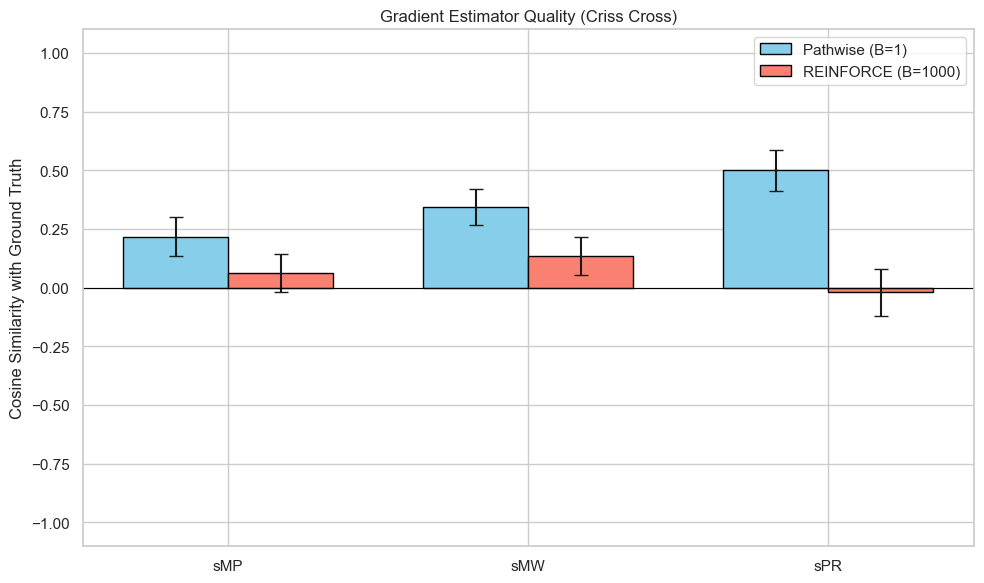

In [3]:
# The user requested to reproduce the figure "only on the criss_cross part".
# The gradient_comparison.json typically contains results for the environment configured in the experiment.
# Based on the project context, we assume this data corresponds to the Criss Cross environment.

# Drop samples where gradients were invalid (NaN)
df = df.dropna()

# Calculate Mean and Standard Error (SEM) for each policy
grouped = df.groupby('policy')[['sim_pathwise', 'sim_reinforce']].agg(['mean', 'sem'])

# Setup plot
policies = grouped.index
x = np.arange(len(policies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Pathwise (Blue)
rects1 = ax.bar(x - width/2, grouped['sim_pathwise']['mean'], width,
                yerr=grouped['sim_pathwise']['sem'], label='Pathwise (B=1)', capsize=5,
                color='skyblue', edgecolor='black')

# Plot REINFORCE (Red)
rects2 = ax.bar(x + width/2, grouped['sim_reinforce']['mean'], width,
                yerr=grouped['sim_reinforce']['sem'], label='REINFORCE (B=1000)', capsize=5,
                color='salmon', edgecolor='black')

# Formatting
ax.set_ylabel('Cosine Similarity with Ground Truth')
ax.set_title('Gradient Estimator Quality (Criss Cross)')
ax.set_xticks(x)
ax.set_xticklabels(policies)
ax.legend()

# Y-axis range [-1, 1]
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


# 5.2

# 5.3

In [4]:
# Load data for admission control summary
summary_path = '../results/admission_control_summary.json'
if not os.path.exists(summary_path):
    summary_path = r'C:/Users/thoma/OneDrive/Bureau/THOMAS/Programmes_Informatiques/ResearchRL/QueueTorch/results/admission_control_summary.json'

with open(summary_path, 'r') as f:
    summary_data = json.load(f)

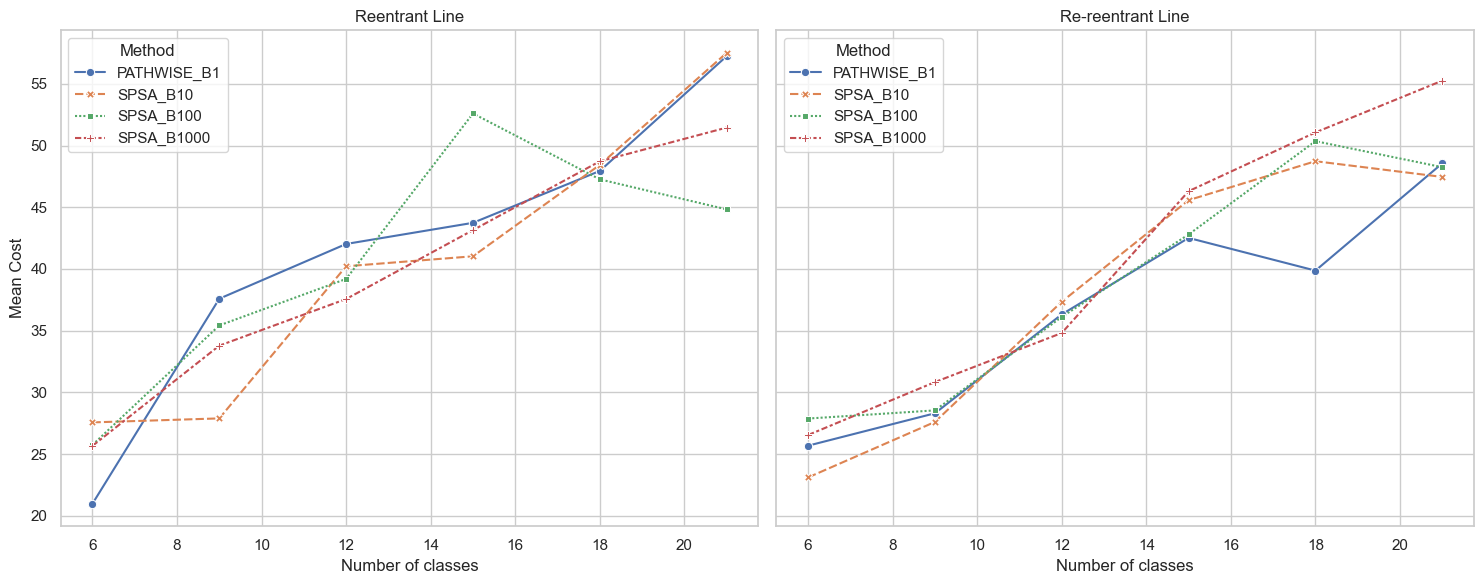

In [6]:
# Extract data for plotting
# We want to plot Mean Cost vs Number of Servers (or Hyper-parameter index)
# The keys are like "reentrant_2_hyper.yaml", "reentrant_3_hyper.yaml", etc.
# We'll extract the number (2, 3, 4...) as the x-axis.

# Separate data into two groups: "reentrant" and "re-reentrant"
reentrant_data = {}
rereentrant_data = {}

for key, value in summary_data.items():
    # Parse key to get type and index
    parts = key.split('_')
    # parts[0] is 'reentrant' or 're-reentrant' (actually 're-reentrant' splits to ['re-reentrant', ...])
    # Let's handle carefully.

    if key.startswith('re-reentrant'):
        idx = int(parts[1])*3 # 're-reentrant_2_hyper.yaml' -> parts=['re-reentrant', '2', 'hyper.yaml']
        rereentrant_data[idx] = value
    elif key.startswith('reentrant'):
        idx = int(parts[1])*3 # 'reentrant_2_hyper.yaml' -> parts=['reentrant', '2', 'hyper.yaml']
        reentrant_data[idx] = value

# Function to prepare dataframe for plotting
def prepare_df(data_dict):
    rows = []
    for idx, methods in data_dict.items():
        for method, stats in methods.items():
            rows.append({
                'Index': idx,
                'Method': method,
                'Mean': stats['mean'],
                'Std': stats['std']
            })
    return pd.DataFrame(rows).sort_values('Index')

df_re = prepare_df(reentrant_data)
df_rere = prepare_df(rereentrant_data)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Define markers/styles for different methods if needed, or rely on seaborn defaults
markers = {'PATHWISE_B1': 'o', 'SPSA_B10': 's', 'SPSA_B100': '^', 'SPSA_B1000': 'D'}

# Plot Reentrant
sns.lineplot(data=df_re, x='Index', y='Mean', hue='Method', style='Method', markers=True, ax=axes[0])
axes[0].set_title('Reentrant Line')
axes[0].set_xlabel('Number of classes')
axes[0].set_ylabel('Mean Cost')

# Plot Re-reentrant
sns.lineplot(data=df_rere, x='Index', y='Mean', hue='Method', style='Method', markers=True, ax=axes[1])
axes[1].set_title('Re-reentrant Line')
axes[1].set_xlabel('Number of classes')
axes[1].set_ylabel('') # Shared Y axis

plt.tight_layout()
plt.show()
